Starting simulation...
Done!


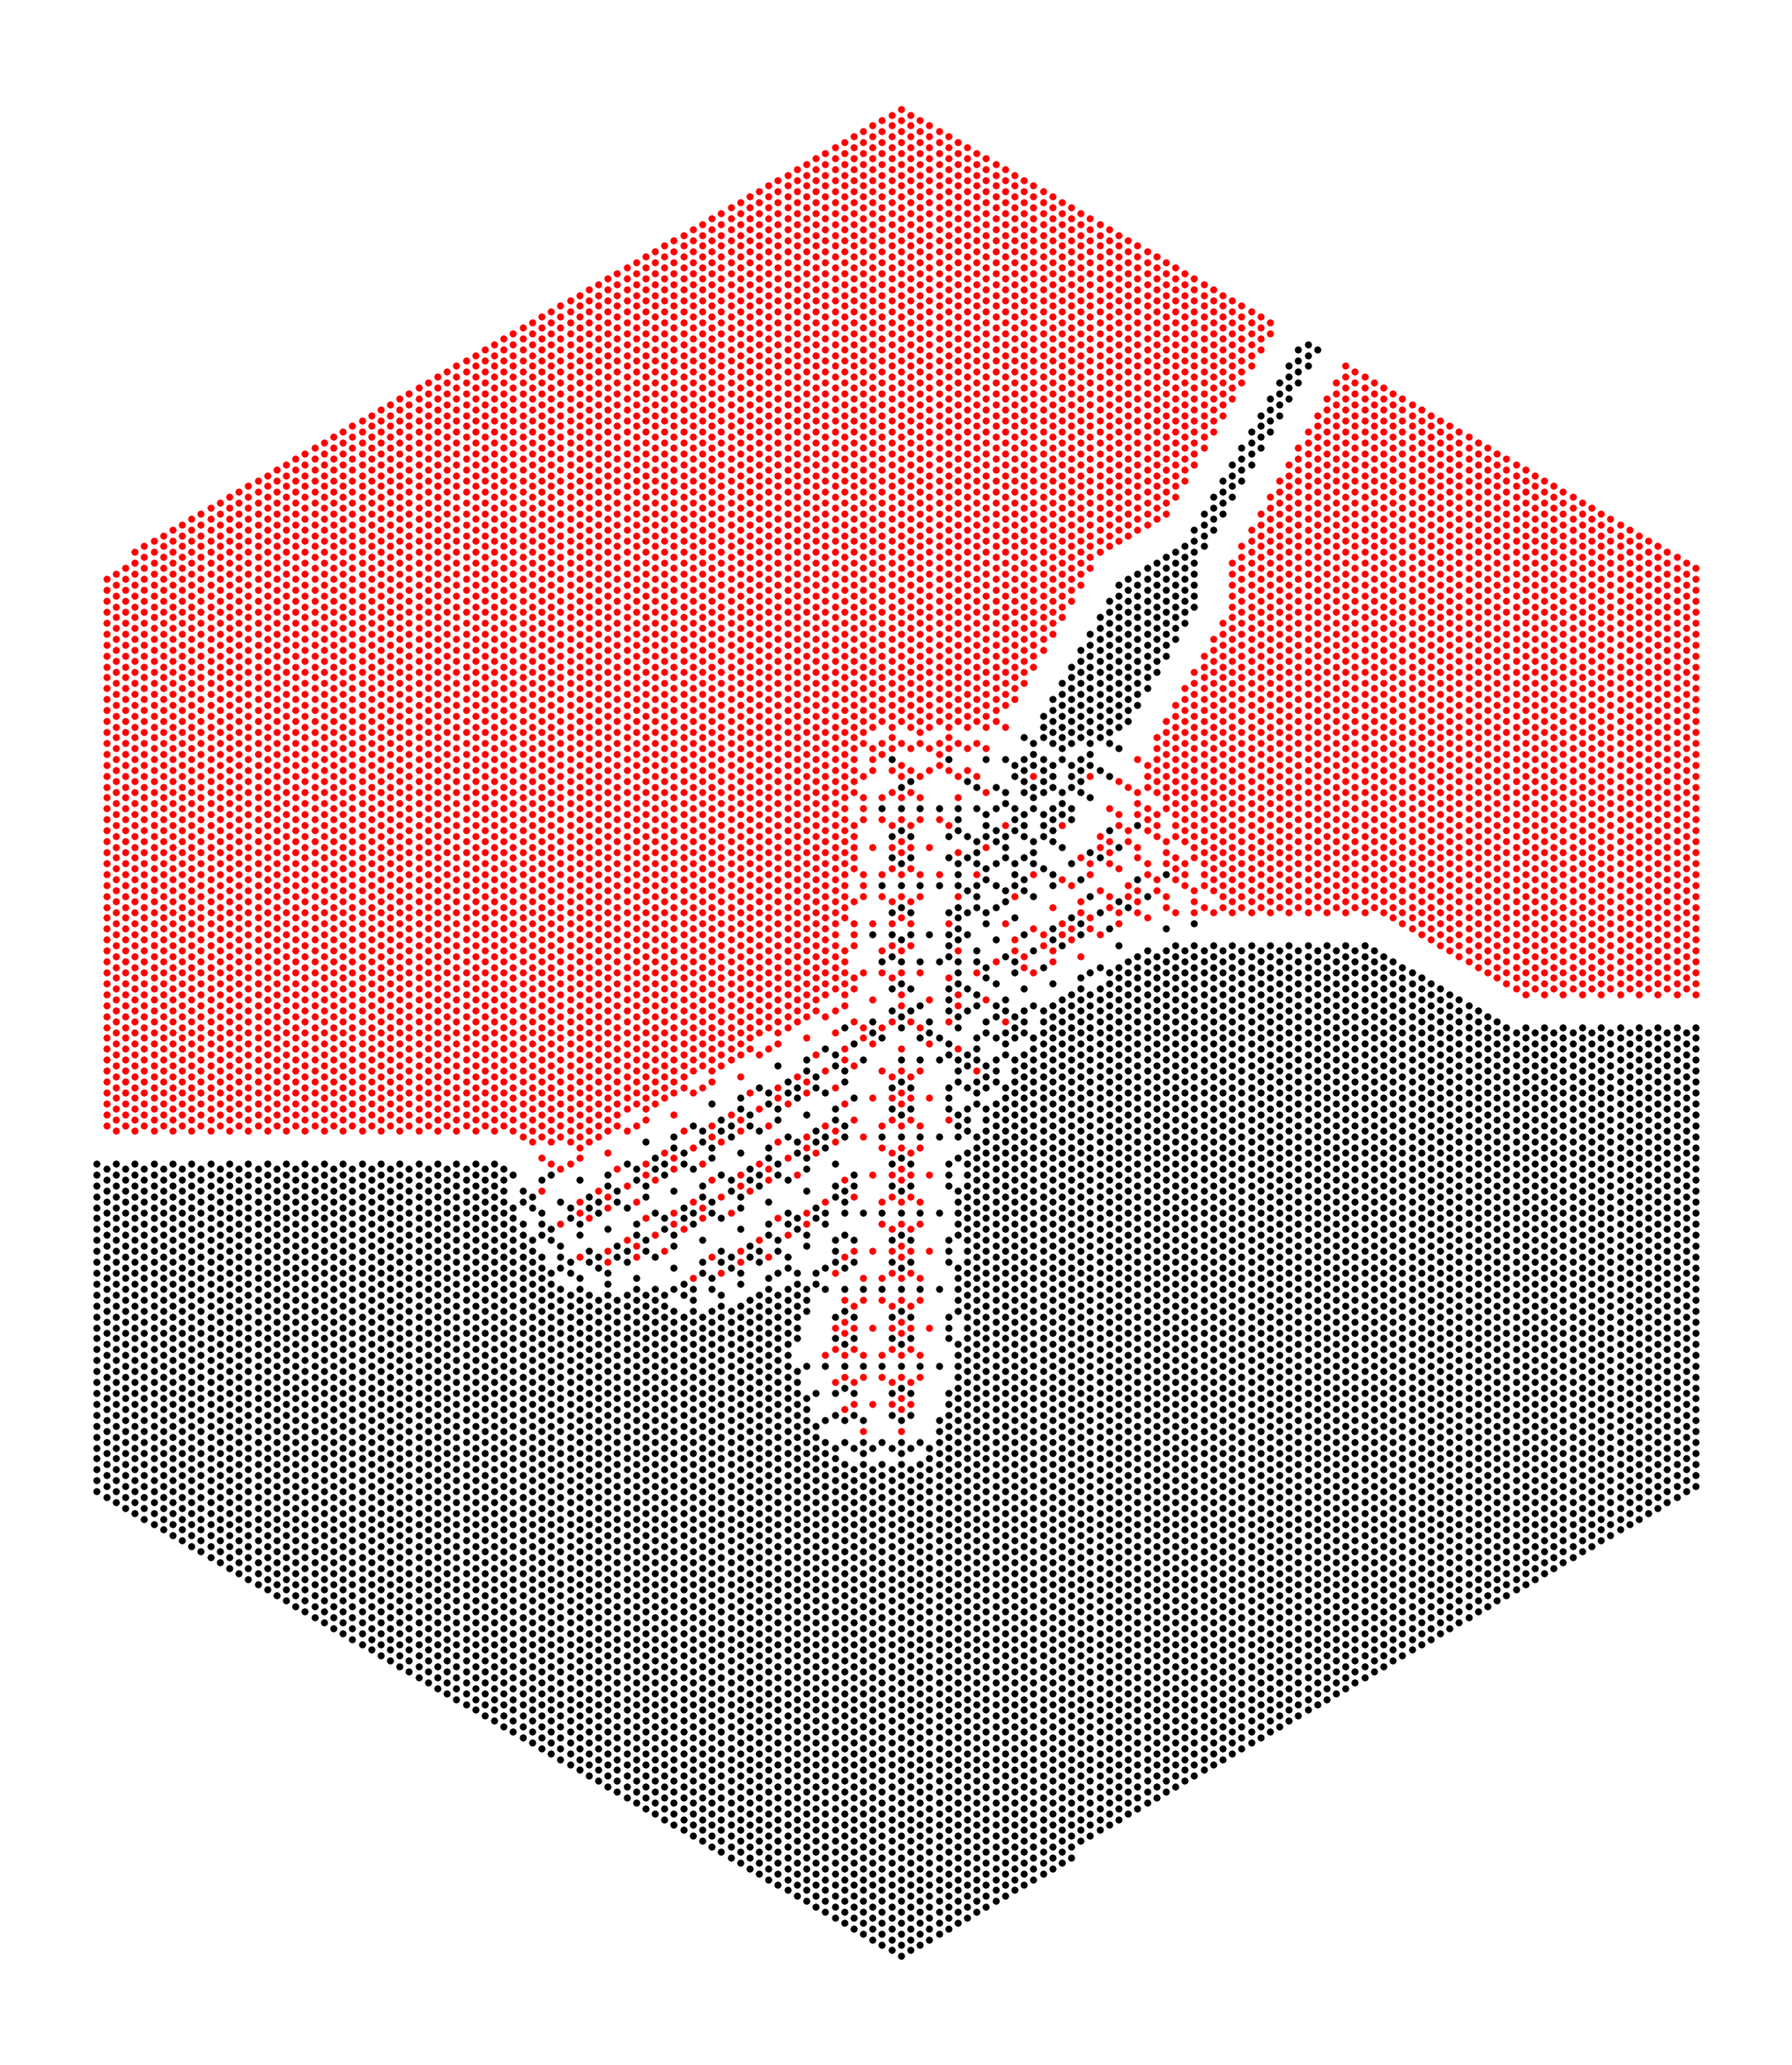

In [3]:
import matplotlib.pyplot as plt
from random import randint

# --- Configuration ---
N = 10**4  # Total pieces per player
K = 2      # Number of players

# --- Hexagonal Logic ---

def hex_step(t):
    """Returns the next coordinate in a hexagonal spiral (Axial coordinates)."""
    (q, r) = t
    s = -q - r
    if (q, r) == (0, 0):
        return (1, 0)
    
    ring = max(abs(q), abs(r), abs(s))
    
    # Logic to traverse the hexagonal ring CCW
    if q == ring and r < 0 and s <= ring: # Right edge
        if r == -ring: return (q, r + 1)
        return (q, r + 1)
    elif s == -ring and q > 0:            # Top-right
        return (q - 1, r + 1)
    elif r == ring and q <= 0:            # Top-left
        return (q - 1, r)
    elif q == -ring and r > 0:            # Left
        return (q, r - 1)
    elif s == ring and q < 0:             # Bottom-left
        return (q + 1, r - 1)
    elif r == -ring and q >= -ring:       # Bottom-right
        if q == ring: return (q + 1, r)   # Step out to next ring
        return (q + 1, r)
    return (q + 1, r) # Safety fallback

def get_hex_knight_moves(t):
    """
    Returns the 12 reachable hexes for a 'knight' on a hex grid.
    Defined as moving 2 steps in one direction and 1 step in another.
    """
    q, r = t
    # These represent the Hex-Knight displacements in Axial (q, r)
    offsets = [
        (2, 1), (1, 2), (-1, 3), (-2, 3), (-3, 2), (-3, 1),
        (-2, -1), (-1, -2), (1, -3), (2, -3), (3, -2), (3, -1)
    ]
    return [(q + dq, r + dr) for dq, dr in offsets]

def axial_to_pixel(q, r):
    """Converts axial (q, r) to Cartesian (x, y) for rendering."""
    x = 1.5 * q
    y = 0.86602540378 * (q + 2 * r) # sqrt(3)/2 * (q + 2r)
    return x, y

# --- Simulation ---

candidates = [(0, 0) for _ in range(K)]
histories = [[] for _ in range(K)]
verboten = [set() for _ in range(K)]

print("Starting simulation...")

for i in range(K * N):
    idx = i % K
    candidate = candidates[idx]
    
    # Skip forbidden hexes
    while candidate in verboten[idx]:
        candidate = hex_step(candidate)
    
    candidates[idx] = candidate
    histories[idx].append(candidate)
    
    # Mark threats
    threatened = get_hex_knight_moves(candidate)
    for j in range(K):
        if j == idx:
            verboten[j].add(candidate) # Cannot occupy own previous spots
        else:
            verboten[j].add(candidate) # Cannot occupy enemy spots
            for t in threatened:
                verboten[j].add(t)     # Cannot occupy spots threatened by enemy

    if (i + 1) % 200000 == 0:
        print(f"Placed {i + 1} pieces...")

# --- Rendering ---

%config InlineBackend.figure_format = 'retina'
fig = plt.figure(figsize=(12, 12), facecolor='white')
ax = fig.add_subplot(111)

# Player 1 (Black)
bx, by = zip(*[axial_to_pixel(q, r) for q, r in histories[0]])
ax.plot(bx, by, marker='o', linestyle='None', color='black', markersize=3, markeredgewidth=0)

# Player 2 (Red)
rx, ry = zip(*[axial_to_pixel(q, r) for q, r in histories[1]])
ax.plot(rx, ry, marker='o', linestyle='None', color='red', markersize=3, markeredgewidth=0)

# clean plot
ax.axis('off')
ax.set_aspect('equal')
plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
plt.margins(0.05, 0.05)

# generate .png
plt.savefig("hex_simulation.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print("Done!")
plt.show()